## multiclass logistic regression 
## on mnist dataset from scratch in python

In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt

In [2]:
!pip install gdown
!gdown --id 1xIYCrCOo3cPIgslEzI11_cQ_2QFROTHv


[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: pip install --upgrade pip
/Users/harshit/Code/machine-ll/venv/lib/python3.13/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xIYCrCOo3cPIgslEzI11_cQ_2QFROTHv
To: /Users/harshit/Code/machine-ll/imachine/classification/data.csv
100%|██████████████████████████████████████| 20.4M/20.4M [00:03<00:00, 5.57MB/s]


In [3]:
data=pd.read_csv("data.csv",header=None)

In [4]:
data.describe()

,0,1,2,3,4,5,6,7,8,9,...,391,392,393,394,395,396,397,398,399,400
count,5000.0,5000.0,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.0,5000.000000
mean,0.0,0.0,1.549060e-07,-0.000002,-0.000004,0.000117,0.000145,0.000080,0.000019,0.000044,...,0.000016,0.000122,0.000034,0.000006,0.000025,0.000009,0.000004,-4.121051e-07,0.0,4.500000
std,0.0,0.0,1.095351e-05,0.000108,0.000285,0.007398,0.007496,0.005057,0.003937,0.003653,...,0.005944,0.009318,0.008125,0.004369,0.004687,0.001564,0.000300,3.091390e-05,0.0,2.872569
min,0.0,0.0,0.000000e+00,-0.007163,-0.010297,-0.029396,-0.028706,-0.045485,-0.054957,-0.042550,...,-0.052807,-0.050588,-0.053324,-0.051814,-0.048580,-0.022029,-0.008572,-2.183926e-03,0.0,0.000000
25%,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,2.000000
50%,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,4.500000
75%,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,7.000000
max,0.0,0.0,7.745302e-04,0.000567,0.012817,0.506215,0.466290,0.254189,0.246560,0.237271,...,0.239926,0.351204,0.447564,0.204862,0.277293,0.075121,0.018903,8.510349e-05,0.0,9.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 401 entries, 0 to 400
dtypes: float64(395), int64(6)
memory usage: 15.3 MB


In [6]:
#that was kind apoint less now wasnt it ?? 
# linkin park 
D0 = data.copy();D1 = data.copy();D2 = data.copy();D3 = data.copy();D4 = data.copy();D5 =data.copy();D6 = data.copy();D7 = data.copy();D8 = data.copy();D9 = data.copy()



In [7]:
datasets = [D0,D1,D2,D3,D4,D5,D6,D7,D8,D9]

In [8]:
for i in range(10):
  for j in range(5000):
    if datasets[i].at[j,400] == i:
      datasets[i].at[j,400] = 1
    else:
      datasets[i].at[j,400] = 0

In [9]:
#TrainTest_datadict['key'][0] ==> X && TrainTest_datadict['key'][1] ==> y
TrainTest_datadict = {}  
 #399 --> X 400 --> y 
for i in range(10):
  X = datasets[i].iloc[:,:399]
  X = X.T
  y = datasets[i].iloc[:,-1]
  y = np.array([y])
  TrainTest_datadict['D'+str(i)] = [X,y]  

In [10]:
itterations = 10000000   #random big value 
alpha = 0.160 
m = 5000
cost_values = []
trained_parameters = []

for trainsets in range(10):
  X = TrainTest_datadict['D'+str(trainsets)][0] 
  y = TrainTest_datadict['D'+str(trainsets)][1]
  weights = np.random.randn(1,399)
  bias = 0 
  costfunc_values = []
  k = 0
  print('Training for dataset '+str(trainsets))
  for i in range(1,itterations+1):
    #logistic function
    z = np.dot(weights,X) + bias 
    hypothesis = 1/(1 + np.exp(-z)) 

    #cost function
    j = 1/m*(-1*(np.sum(y*np.log(hypothesis) + (1-y)*np.log(1-hypothesis))))
    costfunc_values.append(j)
    k+=1

    #gradient decent
    dw =  1/m * np.dot(hypothesis-y,X.T)
    db =  1/m * np.sum(hypothesis-y)
    weights = weights - alpha*dw
    bias = bias - alpha*db

    #stop training
    if i%2000 == 0:
      print('running @ ',j)
    if i%2 == 0:
      if abs(j-costfunc_values[-2])<0.000001:
        if abs(j-costfunc_values[-3])<0.000001:
          break 
  cost_values.append(costfunc_values)  
  trained_parameters.append([weights,bias])      
  print('itteration number:',k)

Training for dataset 0
running @  0.03553539859726734
running @  0.025810018141018725
running @  0.02183920837098628
running @  0.01944728148507166
running @  0.017758368795772105
running @  0.016472579511037568
itteration number: 13166
Training for dataset 1
running @  0.03939339726254052
running @  0.033009240820243695
running @  0.029876585554701532
running @  0.027807764770889937
running @  0.02626287950811024
running @  0.02502674795963447
itteration number: 13378
Training for dataset 2
running @  0.09766456138276684
running @  0.08300705743046936
running @  0.07628150807571092
running @  0.07223668380405798
running @  0.0694525399400473
running @  0.0673678302598451
running @  0.0657142692899008
running @  0.06434758210139833
running @  0.06318352107800856
itteration number: 19196
Training for dataset 3
running @  0.10088461765279469
running @  0.08507494213190368
running @  0.0788462012145488
running @  0.07538424216280283
running @  0.07308730396506305
running @  0.071400317021

In [13]:

for datasetnum in range(10):
  X = TrainTest_datadict['D'+str(datasetnum)][0]
  y = TrainTest_datadict['D'+str(datasetnum)][1]
  weights = trained_parameters[datasetnum][0]
  bias = trained_parameters[datasetnum][1]
  correct_predictions = 0 
  for i in range(5000):
    z = np.dot(weights,X.T.iloc[i,:])+bias
    hypothesis = 1/(1 + np.exp(-z))
    if np.logical_and(hypothesis >= 0.5,y.T[i,0] == 1):
        correct_predictions+=1
    if np.logical_and(hypothesis < 0.5,y.T[i,0] == 0):
        correct_predictions+=1    
  #print(correct_predictions)      
  acc = (correct_predictions/5000)*100
  print('accuracy for dataset '+str(datasetnum)," = ",acc)

accuracy for dataset 0  =  99.58
accuracy for dataset 1  =  99.36
accuracy for dataset 2  =  98.14
accuracy for dataset 3  =  97.96000000000001
accuracy for dataset 4  =  98.56
accuracy for dataset 5  =  97.98
accuracy for dataset 6  =  99.03999999999999
accuracy for dataset 7  =  98.74000000000001
accuracy for dataset 8  =  96.8
accuracy for dataset 9  =  97.46000000000001


In [14]:
inputs = data.iloc[:,:399]
inputs = inputs.T
outputs = data.iloc[:,-1] 
outputs = np.array(outputs)
accuratepredicts = 0                
for i in range(5000):
  probabilities = []
  for j in range(10):
    weights = trained_parameters[j][0]
    bias = trained_parameters[j][1]
    z = np.dot(weights,inputs.iloc[:,i].T)+bias
    hypothesis = 1/(1 + np.exp(-z)) 
    probabilities.append(hypothesis)
  predict = probabilities.index(max(probabilities)) 
  if outputs.T[i] == predict:
    accuratepredicts+=1
print(accuratepredicts)

4681


In [15]:
(accuratepredicts/5000)*100

93.62

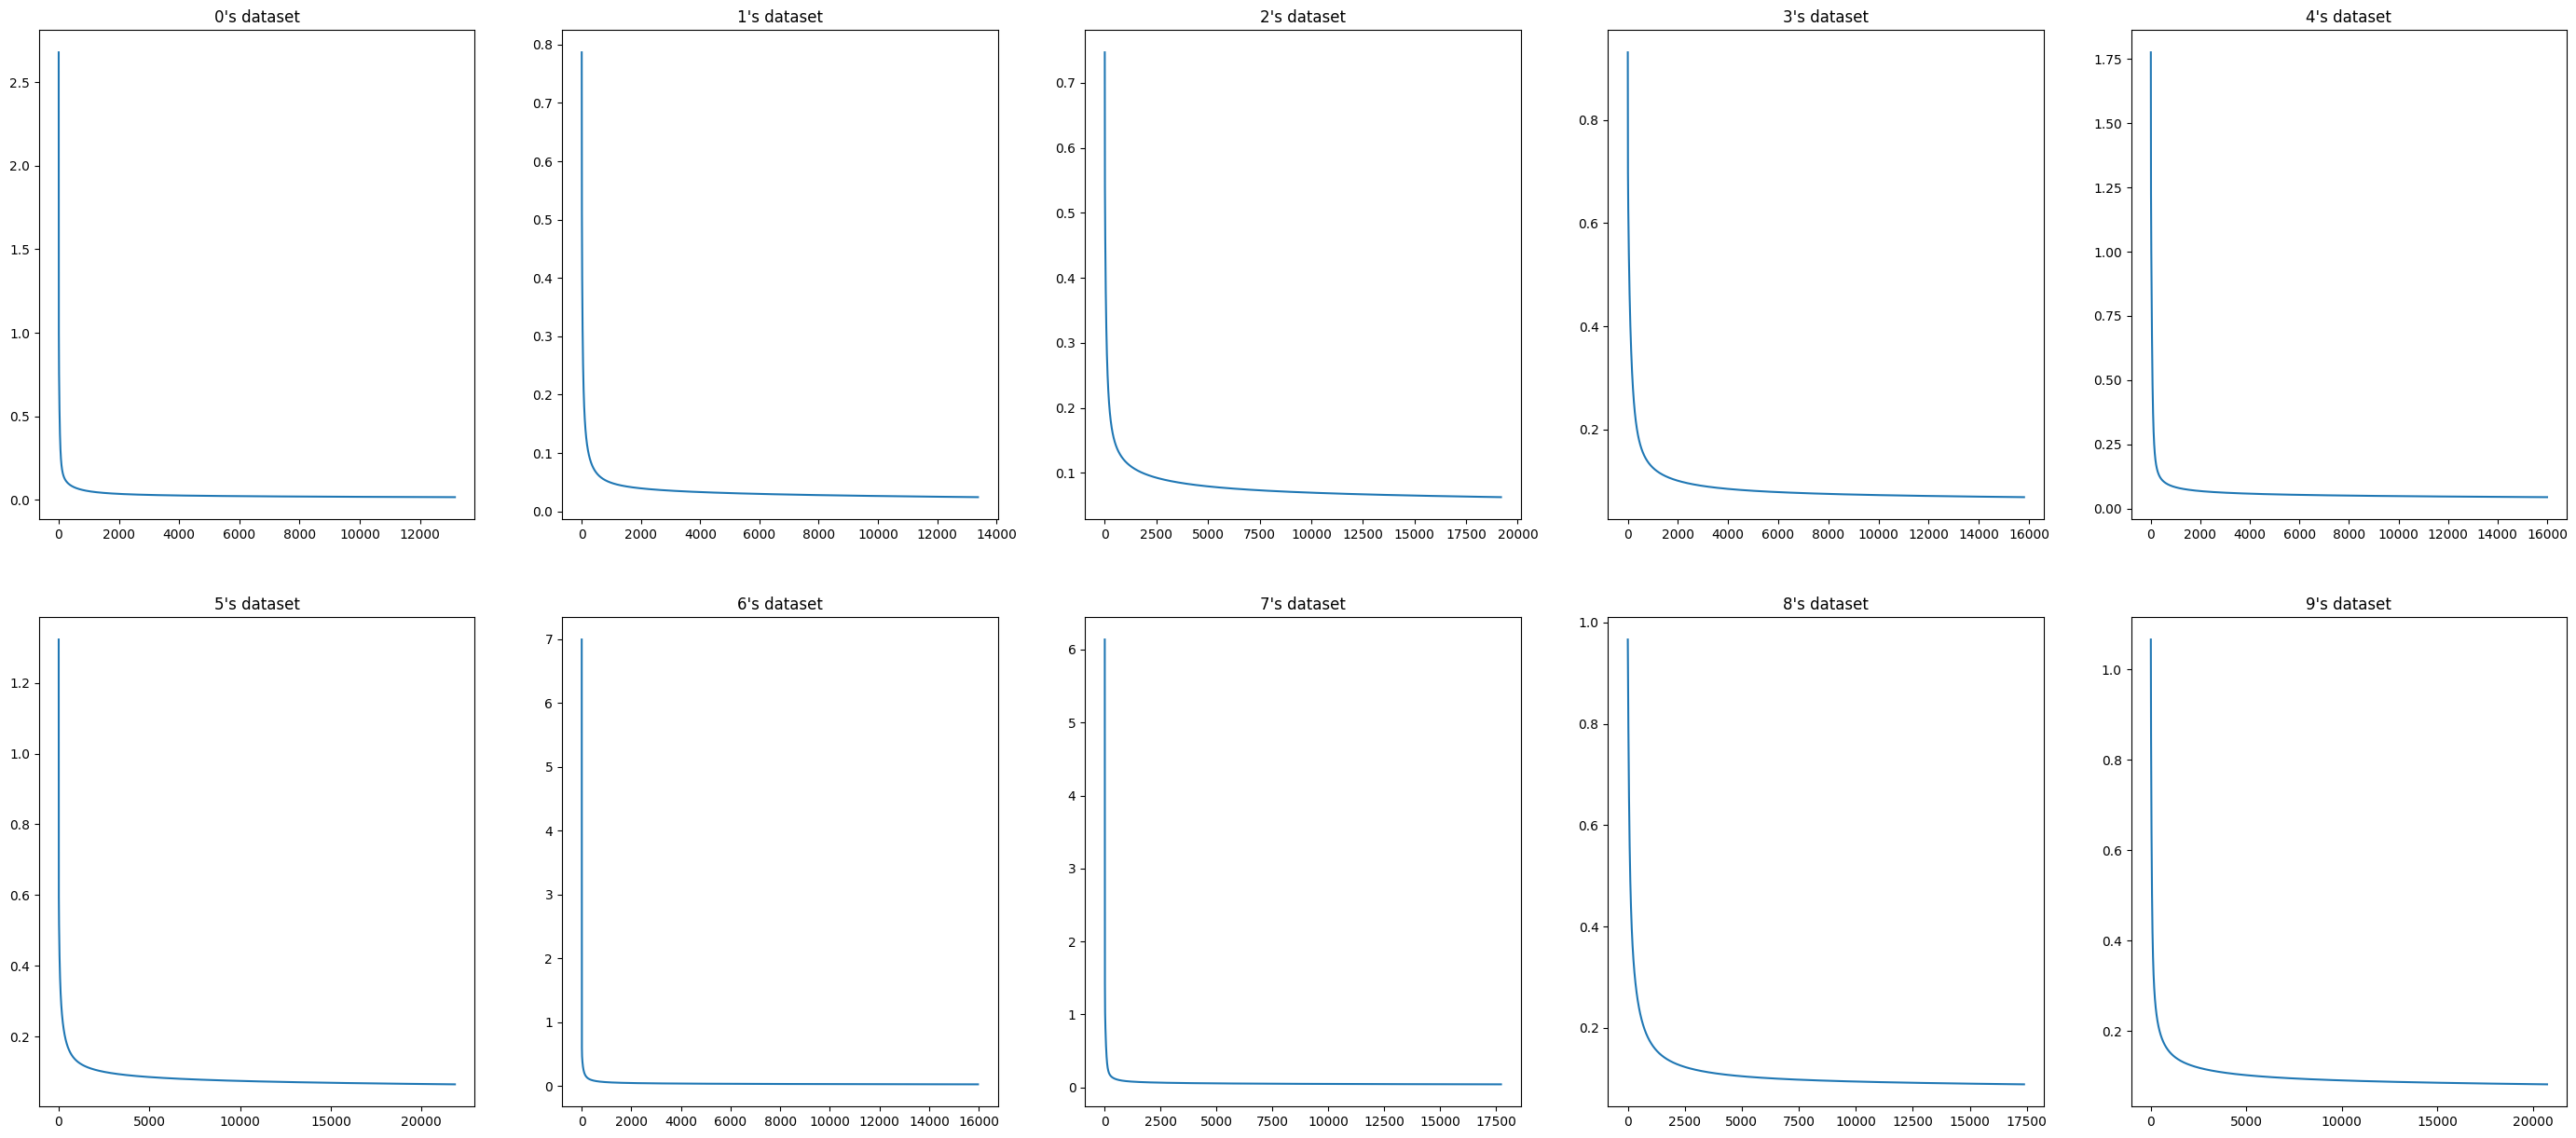

In [16]:
fig,a =  plt.subplots(2,5,figsize=(35,15))
a[0][0].plot(cost_values[0])
a[0][0].set_title("0's dataset")
a[0][1].plot(cost_values[1])
a[0][1].set_title("1's dataset")
a[0][2].plot(cost_values[2])
a[0][2].set_title("2's dataset")
a[0][3].plot(cost_values[3])
a[0][3].set_title("3's dataset")
a[0][4].plot(cost_values[4])
a[0][4].set_title("4's dataset")
a[1][0].plot(cost_values[5])
a[1][0].set_title("5's dataset")
a[1][1].plot(cost_values[6])
a[1][1].set_title("6's dataset")
a[1][2].plot(cost_values[7])
a[1][2].set_title("7's dataset")
a[1][3].plot(cost_values[8])
a[1][3].set_title("8's dataset")
a[1][4].plot(cost_values[9])
a[1][4].set_title("9's dataset")
plt.show()